In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import re

from IPython.display import display

In [2]:
def calculate_apdex(df, threshold=500):
    satisfied = (df['elapsed'] <= threshold).sum()
    tolerating = ((df['elapsed'] > threshold) & (df['elapsed'] <= 4 * threshold)).sum()
    total = len(df)
    return (satisfied + tolerating / 2) / total if total > 0 else 0.0

In [3]:
def process_file(file, apdex_threshold=500):
    df = pd.read_csv(file, sep=';', encoding='utf-8-sig', low_memory=False, dtype={'responseCode': str})
    df.columns = df.columns.str.strip().str.lower()

    df['success'] = df['success'].astype(str).str.lower() == 'true'

    total = len(df)
    success = df['success'].sum()
    error = total - success

    match = re.search(r'Incremental.*?(\d+)', file, re.IGNORECASE)
    users = int(match.group(1)) if match else None

    if not df.empty:
        start_time = df['timestamp'].min()
        end_time = df['timestamp'].max()
        duration_sec = (end_time - start_time) / 1000.0
        throughput = total / duration_sec if duration_sec > 0 else 0
    else:
        throughput = 0

    p90 = df['elapsed'].quantile(0.90) if not df.empty else 0
    p95 = df['elapsed'].quantile(0.95) if not df.empty else 0
    p99 = df['elapsed'].quantile(0.99) if not df.empty else 0

    cache_hit_rate = 0.0
    
    cache_col = None
    for col in df.columns:
        if 'cache' in col and 'status' in col:
            cache_col = col
            break
    
    if cache_col:
        df[cache_col] = df[cache_col].astype(str).str.upper().str.strip()
        
        cache_hit = (df[cache_col] == 'BYPASS').sum()
        total_cache = df[cache_col].isin(['HIT', 'MISS', 'BYPASS']).sum()
        
        cache_hit_rate = (cache_hit / total_cache * 100) if total_cache > 0 else 0
        
    apdex = calculate_apdex(df, threshold=apdex_threshold)

    return {
        'users': users,
        'total_requests': total,
        'success_rate (%)': round(success / total * 100, 2) if total > 0 else 0,
        'error_rate (%)': round(error / total * 100, 2) if total > 0 else 0,
        'avg_response (ms)': round(df['elapsed'].mean(), 2) if not df.empty else 0,
        'p90_response (ms)': round(p90, 2),
        'p95_response (ms)': round(p95, 2),
        'avg_latency (ms)': round(df['latency'].mean(), 2) if not df.empty else 0,
        'avg_connect (ms)': round(df['connect'].mean(), 2) if 'connect' in df.columns and not df.empty else 0,
        'throughput (req/s)': round(throughput, 2),
        'cache bypass (%)': round(cache_hit_rate, 2),
        'apdex': round(apdex, 3),
    }

In [4]:
def analyze_all(pattern="IncrementalReport/Ghost Report - Incremental*.csv", apdex_threshold=500):
    files = glob.glob(pattern)
    if not files:
        print(f"Format file salah: {pattern}")
        return pd.DataFrame()

    results = []
    for f in sorted(files):
        results.append(process_file(f, apdex_threshold))

    df_result = pd.DataFrame(results)

    if df_result['users'].notna().all():
        df_result = df_result.sort_values(by='users').reset_index(drop=True)

    numeric_cols = df_result.select_dtypes(include='number').columns
    avg_values = df_result[numeric_cols].mean()

    avg_row = avg_values.to_dict()
    avg_row['users'] = 'Average'

    df_final = pd.concat([df_result, pd.DataFrame([avg_row])], ignore_index=True)

    cols = ['users'] + [col for col in df_final.columns if col != 'users']
    df_final = df_final[cols]

    return df_final

In [5]:
result = analyze_all("IncrementalReport/Ghost Report - Incremental*.csv", apdex_threshold=500)
result.to_csv("Ghost Report - Incremental Inject Summary.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=2)
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(result)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

users,total_requests,success_rate (%),error_rate (%),avg_response (ms),p90_response (ms),p95_response (ms),avg_latency (ms),avg_connect (ms),throughput (req/s),cache bypass (%),apdex
100,45492.00,100.00,0.00,1189.22,3103.00,3379.00,1172.40,4.70,75.83,100.00,0.58
200,50834.00,86.52,13.48,2129.99,5930.10,6986.00,2099.24,8.05,84.73,100.00,0.47
300,53868.00,81.92,18.08,3016.49,7543.30,9080.65,2991.28,17.68,89.78,100.00,0.41
400,56315.00,76.65,23.35,3878.19,10428.00,12715.90,3801.99,16.04,93.86,100.00,0.40
500,56058.00,77.16,22.84,4987.36,11214.60,13255.15,4382.33,203.29,93.43,100.00,0.35
Average,52513.40,84.45,15.55,3040.25,7643.80,9083.34,2889.45,49.95,87.53,100.00,0.44


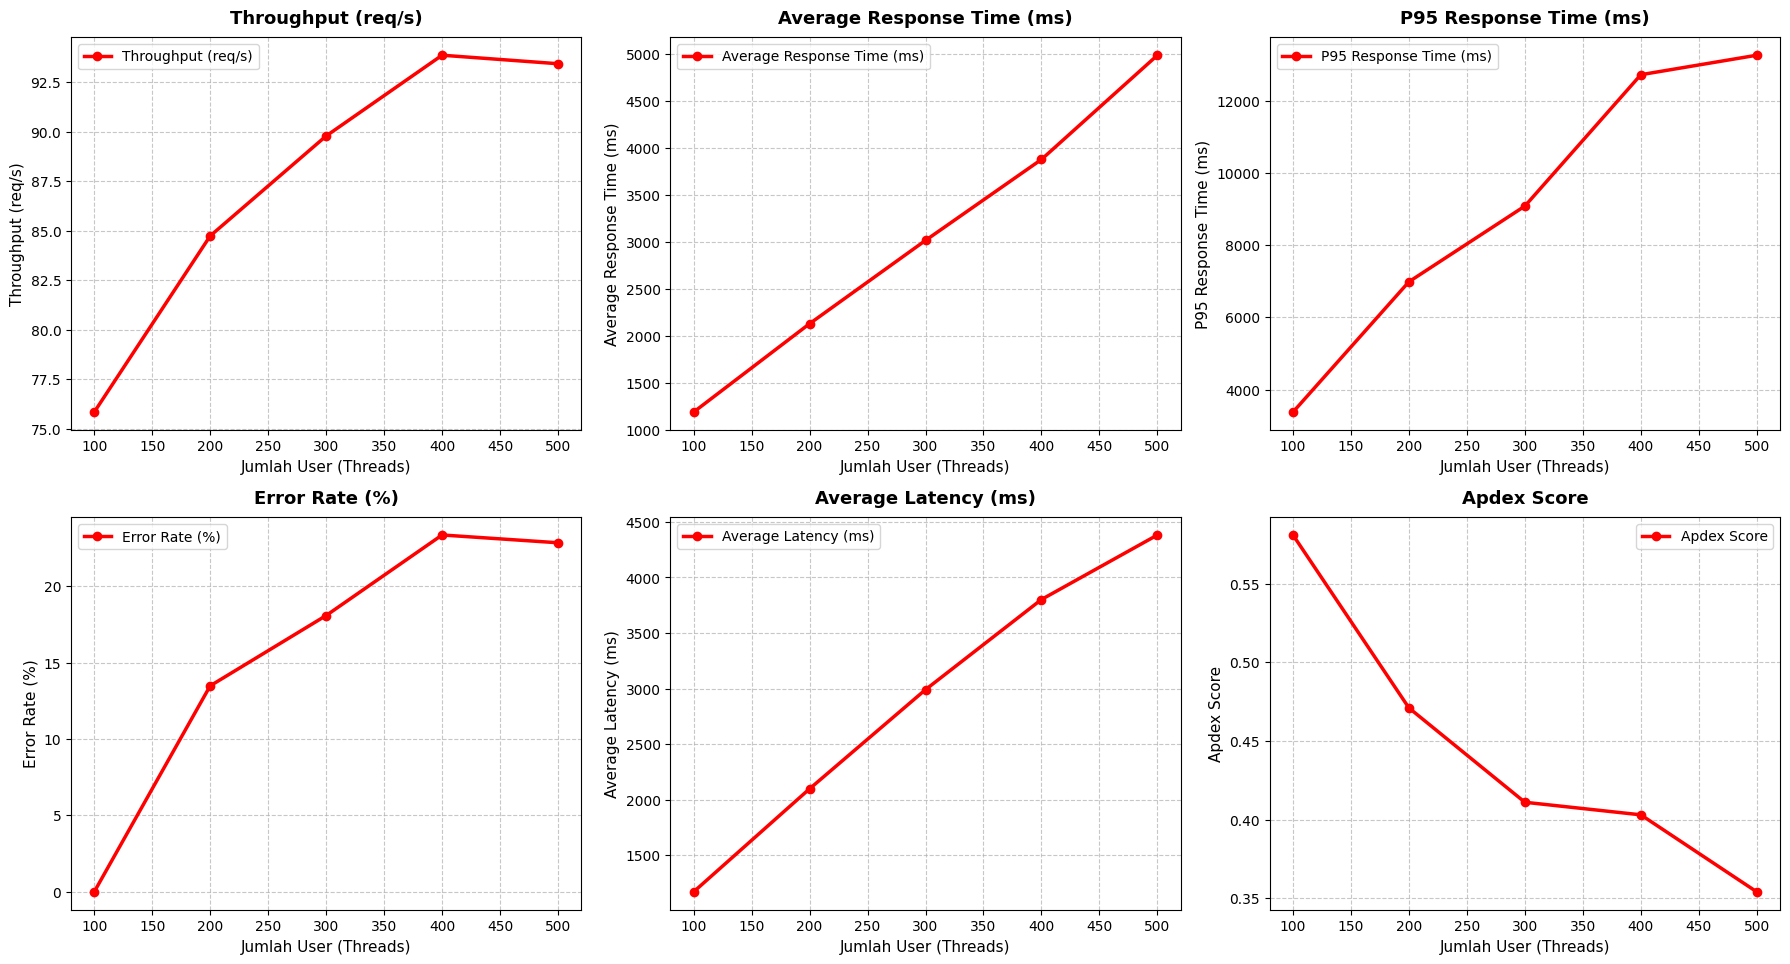

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

x = result['users'][:-1]

metrics = [
    ('throughput (req/s)',    'Throughput (req/s)',          'red'),
    ('avg_response (ms)',     'Average Response Time (ms)',  'red'),
    ('p95_response (ms)',     'P95 Response Time (ms)',      'red'),
    ('error_rate (%)',        'Error Rate (%)',              'red'),
    ('avg_latency (ms)',      'Average Latency (ms)',        'red'),
    ('apdex',                 'Apdex Score',                 'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 3)
    
    axs[row, col_idx].plot(x, result[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Ghost Report - Incremental Inject.png")
plt.show()

In [7]:
def clean_cpu(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    value = float(match.group(1))
    if 'm' in val_str:
        return value
    else:
        return value * 1000

In [8]:
def clean_memory(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    
    value = float(match.group(1))
    
    if 'gi' in val_str:
        return value * 1024
    elif 'mi' in val_str or 'mib' in val_str:
        return value
    elif 'ki' in val_str:
        return value / 1024
    else:
        return value

In [9]:
pattern = "IncrementalResult/log_ghost-incremental*.csv"
files = glob.glob(pattern)

results = []
for file in sorted(files):
    try:
        match = re.search(r'_inject-(\d+)-user', file)
        user_count = int(match.group(1)) if match else 0
        
        df = pd.read_csv(file)
        
        df['CPU_cleaned'] = df['App_CPU_m'].apply(clean_cpu)
        df['Memory_cleaned'] = df['App_Memory_Mi'].apply(clean_memory)
        df['Ingress_CPU_cleaned'] = df['Ingress_CPU_m'].apply(clean_cpu)
        df['Ingress_Memory_cleaned'] = df['Ingress_Memory_Mi'].apply(clean_memory)

        pods = df['Pod_Name'][df['Pod_Name'].str.startswith('ghost-deployment', na=False)]
        pod_count = pods.nunique()
        
        avg_cpu = df['CPU_cleaned'].mean()
        max_cpu = df['CPU_cleaned'].max()
        avg_mem = df['Memory_cleaned'].mean()
        max_mem = df['Memory_cleaned'].max()
        avg_ingress_cpu = df['Ingress_CPU_cleaned'].mean()
        max_ingress_cpu = df['Ingress_CPU_cleaned'].max()
        avg_ingress_mem = df['Ingress_Memory_cleaned'].mean()
        max_ingress_mem = df['Ingress_Memory_cleaned'].max()
        
        results.append({
            'Users': user_count,
            'Replicas': int(pod_count),
            'Avg CPU (m)': round(avg_cpu, 2),
            'Max CPU (m)': round(max_cpu, 2),
            'Avg Memory (Mi)': round(avg_mem, 2),
            'Max Memory (Mi)': round(max_mem, 2),
            'Avg Ingress CPU (m)': round(avg_ingress_cpu, 2),
            'Max Ingress CPU (m)': round(max_ingress_cpu, 2),
            'Avg Ingress Memory (Mi)': round(avg_ingress_mem, 2),
            'Max Ingress Memory (Mi)': round(max_ingress_mem, 2),
            'Samples': len(df)
        })
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='Users').reset_index(drop=True)

In [10]:
numeric_cols = ['Avg CPU (m)', 'Replicas', 'Max CPU (m)', 'Avg Memory (Mi)', 'Max Memory (Mi)', 'Avg Ingress CPU (m)', 'Max Ingress CPU (m)', 'Avg Ingress Memory (Mi)', 'Max Ingress Memory (Mi)', 'Samples']
avg_row = summary_df[numeric_cols].mean()
avg_row['Users'] = 'Average'

summary = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
summary.to_csv("Ghost Result - Incremental Inject Summary.csv", index=False)

styled = (summary.style
          .hide(axis="index")
          .format(precision=2)
          .format(subset=['Replicas', 'Samples'], formatter="{:.0f}")
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(summary)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

Users,Replicas,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi),Avg Ingress CPU (m),Max Ingress CPU (m),Avg Ingress Memory (Mi),Max Ingress Memory (Mi),Samples
100,4,315.95,856.00,232.95,512.00,42.91,47.00,57.23,58.00,542
200,4,332.14,898.00,257.79,517.00,44.73,79.00,59.59,61.00,525
300,4,332.59,954.00,261.65,523.00,45.78,75.00,64.42,67.00,501
400,4,266.59,967.00,234.77,504.00,37.67,90.00,65.43,72.00,646
500,4,338.83,895.00,248.14,509.00,48.23,97.00,72.77,77.00,491
Average,4,317.22,914.00,247.06,513.00,43.86,77.60,63.89,67.00,541


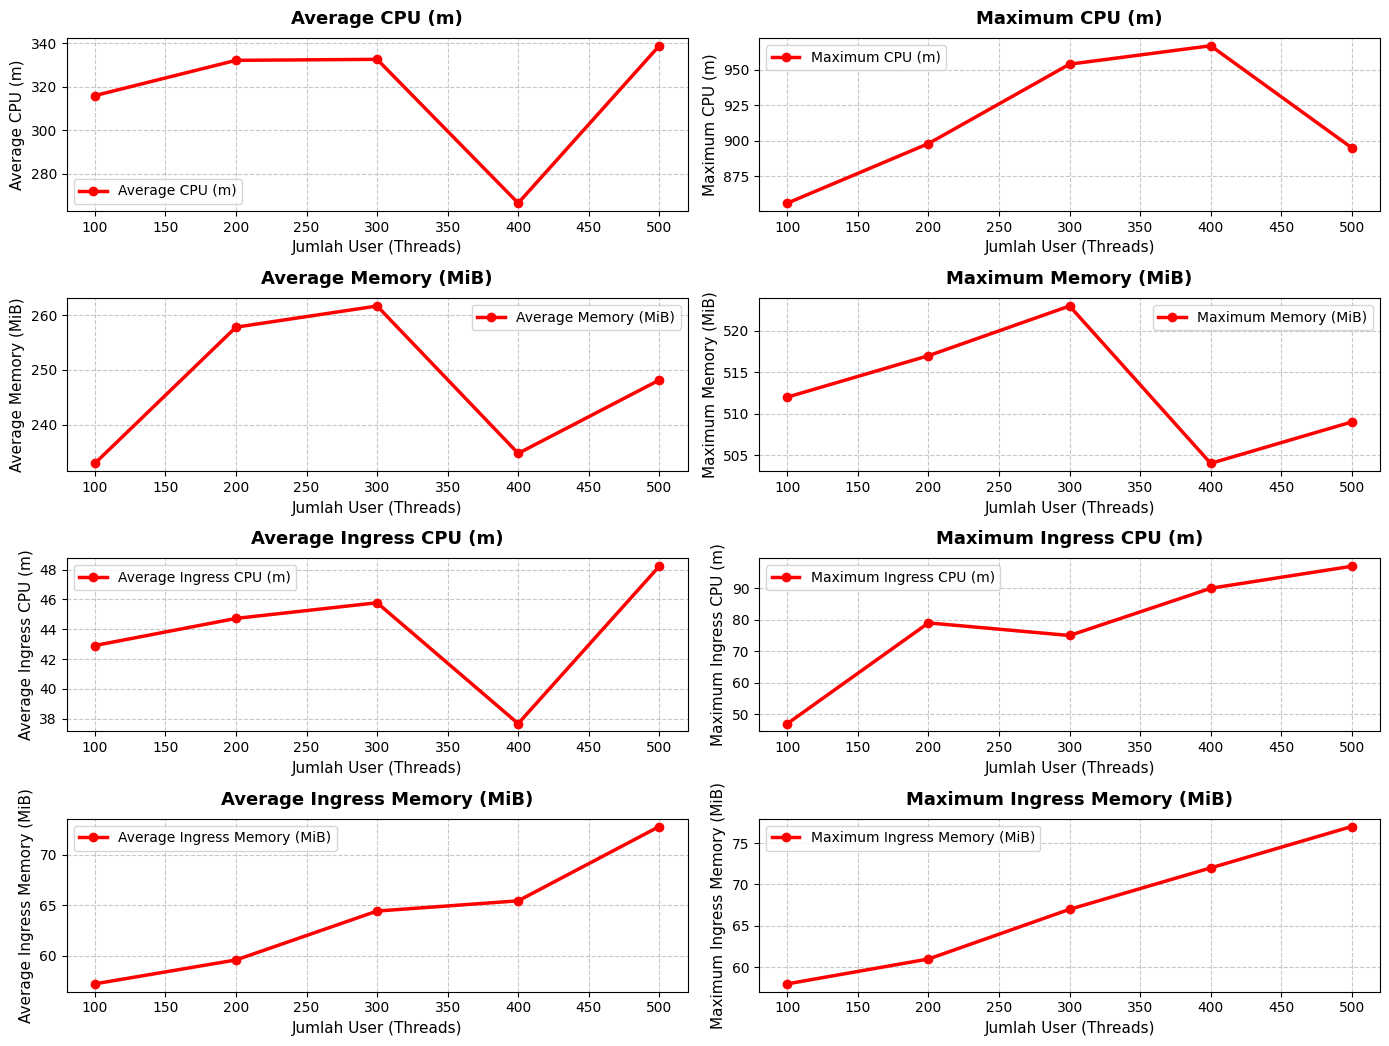

In [11]:
fig, axs = plt.subplots(4, 2, figsize=(14, 11))

x = summary['Users'][:-1]

metrics = [
    ('Avg CPU (m)',             'Average CPU (m)',              'red'),
    ('Max CPU (m)',             'Maximum CPU (m)',              'red'),
    ('Avg Memory (Mi)',         'Average Memory (MiB)',         'red'),
    ('Max Memory (Mi)',         'Maximum Memory (MiB)',         'red'),
    ('Avg Ingress CPU (m)',     'Average Ingress CPU (m)',      'red'),
    ('Max Ingress CPU (m)',     'Maximum Ingress CPU (m)',      'red'),
    ('Avg Ingress Memory (Mi)', 'Average Ingress Memory (MiB)', 'red'),
    ('Max Ingress Memory (Mi)', 'Maximum Ingress Memory (MiB)', 'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 2)
    
    axs[row, col_idx].plot(x, summary[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Ghost Result - Incremental Inject.png")
plt.show()

In [12]:
pattern = "IncrementalKernel/log-kernel-monitoring_ghost-incremental*.csv"
files = glob.glob(pattern)

results = []
for file in sorted(files):
    try:
        match = re.search(r'_inject-(\d+)-user', file)
        user_count = int(match.group(1)) if match else 0
        
        df = pd.read_csv(file)
        
        df['CPU_Total'] = df['CPU_User'] + df['CPU_System']
        df['Memory_Total'] = df['Mem_Free_MB'] + df['Mem_Cache_MB']
        df['IO_Total'] = df['IO_Read_S'] + df['IO_Write_S']

        avg_cpu = df['CPU_Total'].mean()
        max_cpu = df['CPU_Total'].max()
        iowait = df['CPU_IOWait'].mean()
        
        load_avg = df['Load_Avg'].mean()

        avg_mem = df['Memory_Total'].mean()
        max_mem = df['Memory_Total'].max()

        avg_io = df['IO_Total'].mean()
        max_io = df['IO_Total'].max()
        
        duration_minutes = (df['Epoch'].max() - df['Epoch'].min()) / 60 if not df.empty else 0
        
        context_switches = df['Context_Switches'].mean()
        
        results.append({
            'Users': user_count,
            'Avg CPU (%)': round(avg_cpu, 2),
            'Max CPU (%)': round(max_cpu, 2),
            'CPU IOWait': round(iowait, 2),
            'Load Avg': round(load_avg, 2),
            'Avg Memory (MB)': round(avg_mem, 2),
            'Max Memory (MB)': round(max_mem, 2),
            'Avg I/O (S)': round(avg_io, 2),
            'Max I/O (S)': round(max_io, 2),
            'Context Switches': round(context_switches, 2),
            'Duration (s)': round(duration_minutes, 1),
            'Samples': len(df),
        })
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='Users').reset_index(drop=True)

In [13]:
numeric_cols = ['Avg CPU (%)', 'Max CPU (%)', 'CPU IOWait', 'Load Avg', 'Avg Memory (MB)', 'Max Memory (MB)', 'Avg I/O (S)', 'Max I/O (S)', 'Context Switches', 'Duration (s)', 'Samples']
avg_row = summary_df[numeric_cols].mean()
avg_row['Users'] = 'Average'

summary = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
summary.to_csv("Ghost Kernel - Incremental Inject Summary.csv", index=False)

styled = (summary.style
          .hide(axis="index")
          .format(precision=2)
          .format(subset=['Context Switches', 'Samples'], formatter="{:.0f}")
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(summary)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

Users,Avg CPU (%),Max CPU (%),CPU IOWait,Load Avg,Avg Memory (MB),Max Memory (MB),Avg I/O (S),Max I/O (S),Context Switches,Duration (s),Samples
100,91.67,101.00,0.77,17.98,4021.10,4505.00,1499.47,29420.00,21071,10.40,88
200,88.70,101.00,0.46,18.33,3948.04,4380.00,744.94,5564.00,20845,10.60,90
300,90.59,101.00,0.48,17.98,3915.02,4348.00,888.53,6712.00,21296,10.30,87
400,76.65,101.00,0.91,14.69,3885.34,4301.00,885.11,8456.00,20154,12.80,108
500,94.35,101.00,0.36,19.18,3844.56,4298.00,1283.98,13696.00,22003,9.90,84
Average,88.39,101.00,0.60,17.63,3922.81,4366.40,1060.41,12769.60,21074,10.80,91


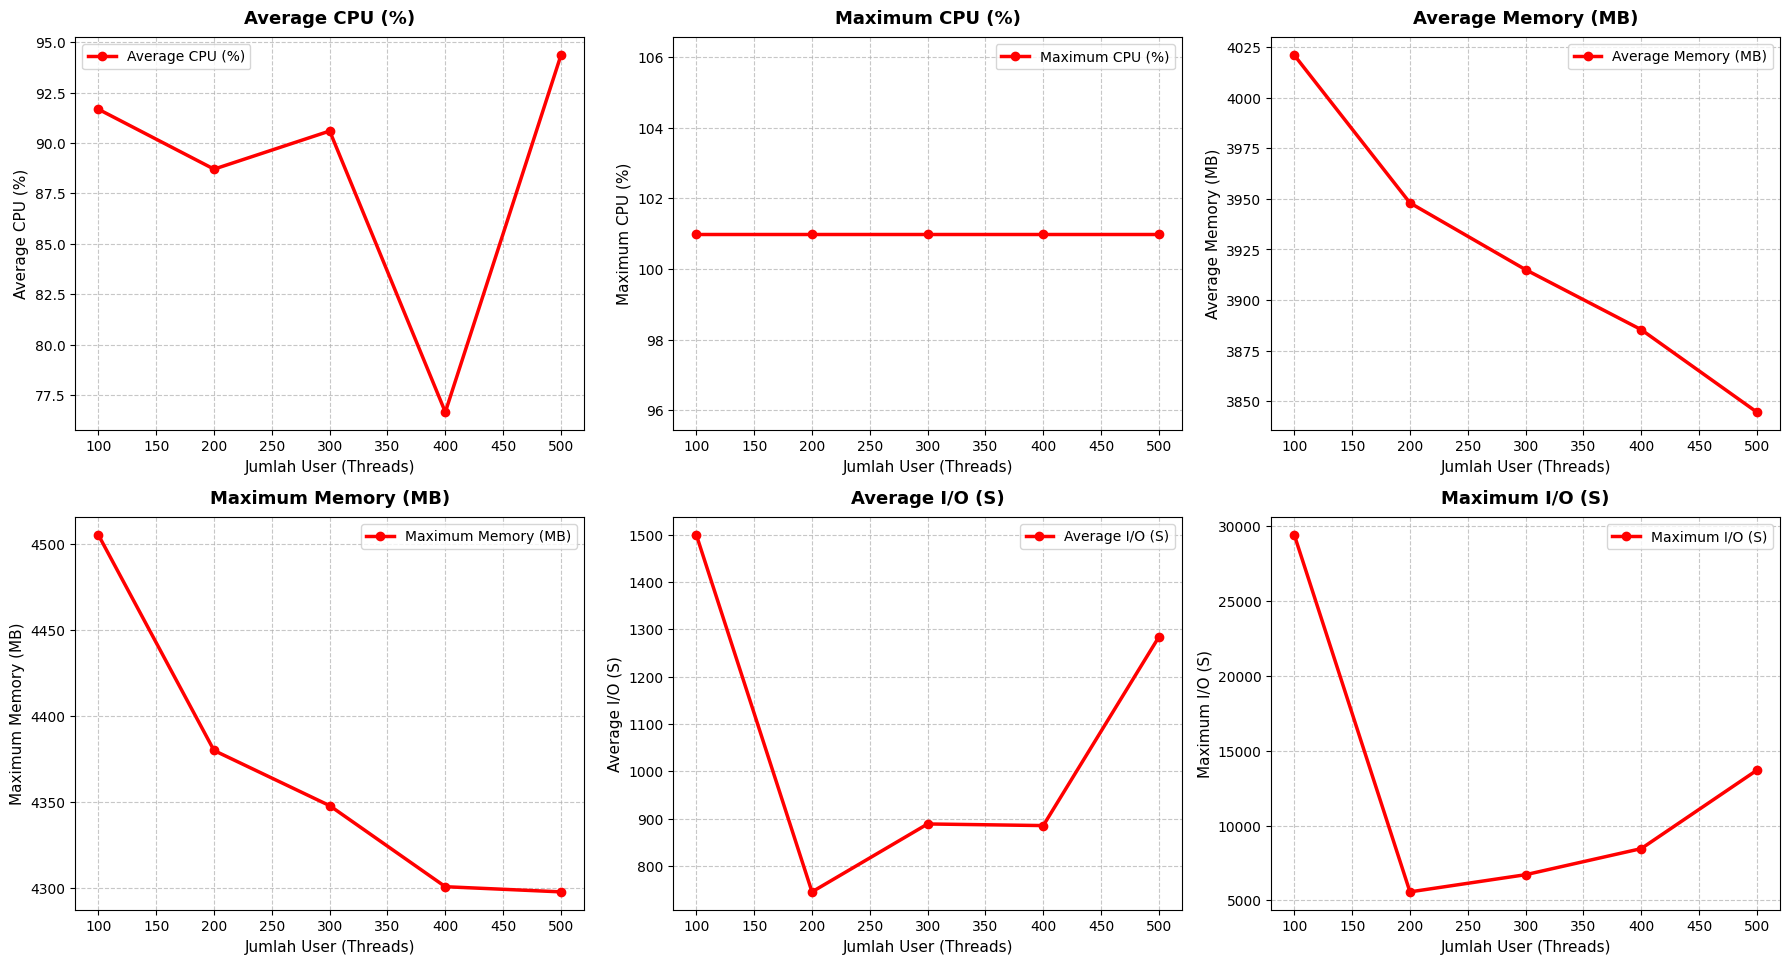

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

x = summary['Users'][:-1]

metrics = [
    ('Avg CPU (%)',     'Average CPU (%)',            'red'),
    ('Max CPU (%)',     'Maximum CPU (%)',            'red'),
    ('Avg Memory (MB)', 'Average Memory (MB)',        'red'),
    ('Max Memory (MB)', 'Maximum Memory (MB)',        'red'),
    ('Avg I/O (S)',     'Average I/O (S)',            'red'), 
    ('Max I/O (S)',     'Maximum I/O (S)',            'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 3)
    
    axs[row, col_idx].plot(x, summary[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

for j in range(6, 9):
    axs.flat[j].set_visible(False)
    
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Ghost Kernel - Incremental Inject.png")
plt.show()